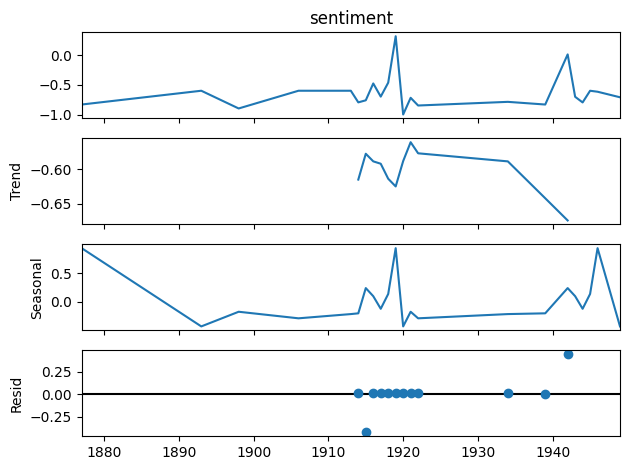

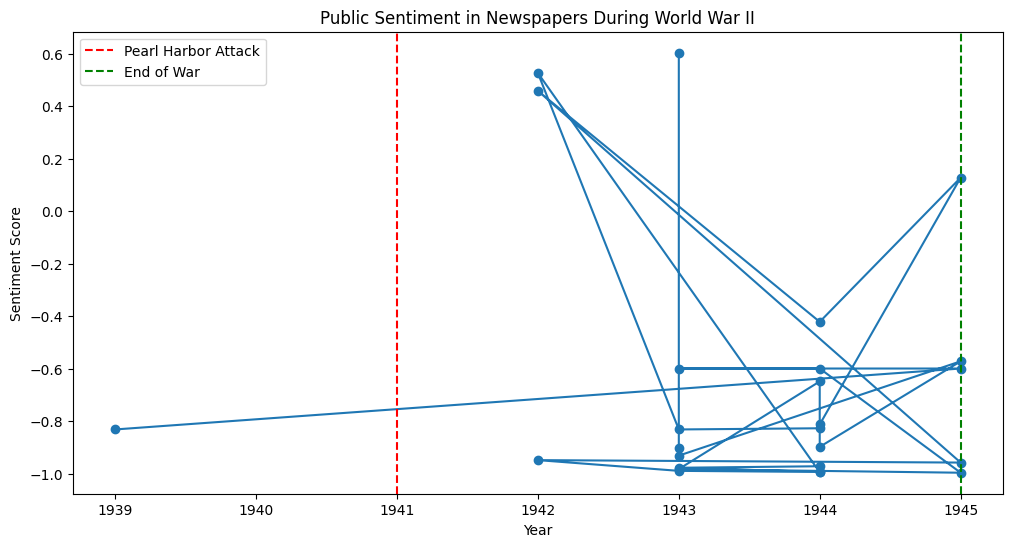

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Define the API endpoint
base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"

# Example query parameters
params = {
    'format': 'json',
    'proxtext': 'war',
    'date1': '1910',
    'date2': '1950',
    'rows': 100
}

# Fetch data
response = requests.get(base_url, params=params)
data = response.json()

# Extract relevant fields
articles = []
for item in data['items']:
    articles.append({
        'date': item['date'],
        'title': item['title'],
        'text': item['ocr_eng']  # Extract OCR-processed text
    })

# Convert to DataFrame
df = pd.DataFrame(articles)
df['date'] = pd.to_datetime(df['date'])
df.head()
# Extract relevant fields
articles = []
for item in data['items']:
    articles.append({
        'date': item['date'],
        'title': item['title'],
        'text': item['ocr_eng']  # Extract OCR-processed text
    })
# Convert to DataFrame
df = pd.DataFrame(articles)
df['date'] = pd.to_datetime(df['date'])
df.head()

import re

def clean_text(text):
    text = re.sub(r'\n+', ' ', text)  # Remove line breaks
    text = re.sub(r'\W+', ' ', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    return text

df['clean_text'] = df['text'].apply(clean_text)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])



# Group by year and compute average sentiment
df['year'] = df['date'].dt.year
sentiment_trends = df.groupby('year')['sentiment'].mean().reset_index()



from statsmodels.tsa.seasonal import seasonal_decompose

# Set the date as the index
sentiment_trends.set_index('year', inplace=True)

# Decompose the sentiment time series
decomposition = seasonal_decompose(sentiment_trends['sentiment'], model='additive', period=10)

# Plot the decomposition
decomposition.plot()
plt.savefig("sentiment_decomposition.png")
plt.show()


df_ww2 = df[(df['year'] >= 1939) & (df['year'] <= 1945)]

# Group by year for WWII period
df_ww2_grouped = df_ww2.groupby('year')['sentiment'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_ww2_grouped['year'], df_ww2_grouped['sentiment'], marker='o', linestyle='-')
plt.axvline(x=1941, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=1945, color='g', linestyle='--', label="End of War")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.title("Average Public Sentiment in Newspapers During World War II")
plt.legend()
plt.savefig("ww2_avg_sentiment_trends.png")
plt.show()


In [ ]:
  import nltk
  nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
  import nltk
  nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
  import nltk
  nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
df_ww2.shape

(26, 5)

In [ ]:
df_ww2.set_index('date', inplace=True)

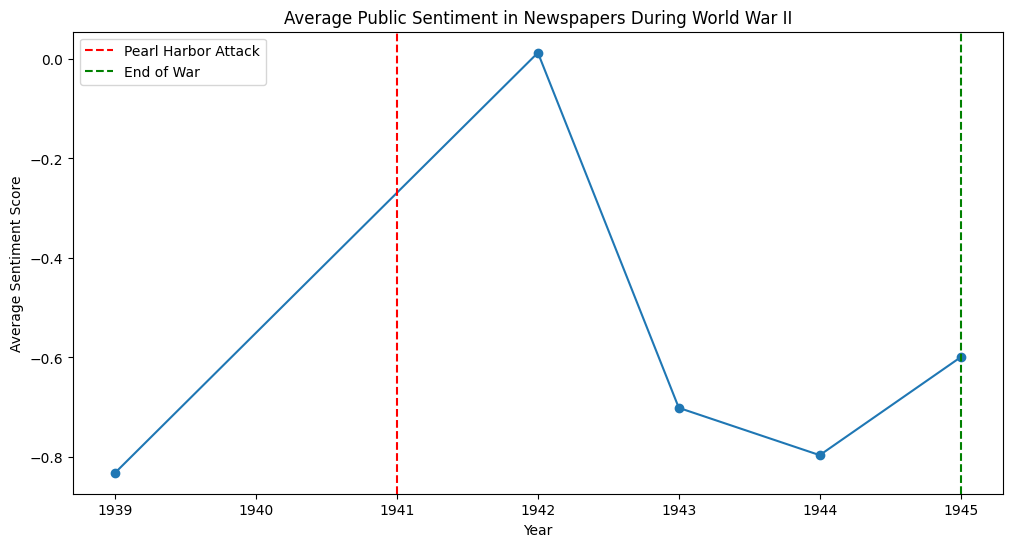

In [ ]:

# Group by year for WWII period
df_ww2_grouped = df_ww2.groupby('year')['sentiment'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_ww2_grouped['year'], df_ww2_grouped['sentiment'], marker='o', linestyle='-')
plt.axvline(x=1941, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=1945, color='g', linestyle='--', label="End of War")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Score")
plt.title("Average Public Sentiment in Newspapers During World War II")
plt.legend()
plt.savefig("ww2_avg_sentiment_trends.png")
plt.show()


In [ ]:
len(df_ww2)

26

In [ ]:
import requests
import pandas as pd
import time

search_terms = ['war', 'battle', 'army', 'conflict', 'peace']
all_articles = []

base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"
max_pages = 20  # Adjust this to collect more or fewer articles per term

for term in search_terms:
    print(f"Fetching articles for term: '{term}'")
    for page in range(1, max_pages + 1):
        params = {
            'format': 'json',
            'proxtext': term,
            'date1': '1910',
            'date2': '1950',
            'rows': 100,
            'page': page
        }
        try:
            response = requests.get(base_url, params=params, timeout=10)
            data = response.json()

            for item in data.get('items', []):
                all_articles.append({
                    'search_term': term,
                    'date': item.get('date', None),
                    'title': item.get('title', ''),
                    'text': item.get('ocr_eng', '')
                })

            time.sleep(1)  # Respectful delay to avoid overwhelming the API
        except Exception as e:
            print(f"Error fetching page {page} for term '{term}': {e}")
            break  # Stop paging for this term if there's an issue

# Convert to DataFrame
df = pd.DataFrame(all_articles)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])  # Remove any entries without valid dates

print(f"Total articles collected: {len(df)}")
df.head()


Fetching articles for term: 'war'


KeyboardInterrupt: 

In [ ]:
import requests
import pandas as pd
import time
import random

search_terms = ['war', 'battle', 'army', 'conflict', 'peace']
all_articles = []

base_url = "https://chroniclingamerica.loc.gov/search/pages/results/"
max_pages = 20
max_retries = 3

for term in search_terms:
    print(f"\nFetching articles for term: '{term}'")
    for page in range(1, max_pages + 1):
        retries = 0
        while retries < max_retries:
            try:
                params = {
                    'format': 'json',
                    'proxtext': term,
                    'date1': '1910',
                    'date2': '1950',
                    'rows': 100,
                    'page': page
                }
                response = requests.get(base_url, params=params, timeout=30)
                response.raise_for_status()
                data = response.json()

                if not data.get('items'):
                    print(f"Page {page}: No more results.")
                    break

                for item in data['items']:
                    all_articles.append({
                        'search_term': term,
                        'date': item.get('date'),
                        'title': item.get('title', ''),
                        'text': item.get('ocr_eng', '')
                    })

                # Random delay between 1 and 3 seconds
                time.sleep(random.uniform(1, 3))
                break  # success, break retry loop

            except Exception as e:
                retries += 1
                wait_time = retries * 5
                print(f"Error on page {page} for term '{term}', retry {retries}/{max_retries}: {e}")
                time.sleep(wait_time)
        else:
            print(f"Failed to fetch page {page} for term '{term}' after {max_retries} retries. Skipping...")

# Convert to DataFrame
df = pd.DataFrame(all_articles)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

print(f"\nTotal articles collected: {len(df)}")
df.head()



Fetching articles for term: 'war'

Fetching articles for term: 'battle'
Error on page 6 for term 'battle', retry 1/3: HTTPSConnectionPool(host='chroniclingamerica.loc.gov', port=443): Read timed out. (read timeout=30)
Error on page 14 for term 'battle', retry 1/3: HTTPSConnectionPool(host='chroniclingamerica.loc.gov', port=443): Read timed out. (read timeout=30)
Error on page 15 for term 'battle', retry 1/3: HTTPSConnectionPool(host='chroniclingamerica.loc.gov', port=443): Read timed out. (read timeout=30)
Error on page 19 for term 'battle', retry 1/3: HTTPSConnectionPool(host='chroniclingamerica.loc.gov', port=443): Read timed out. (read timeout=30)

Fetching articles for term: 'army'
Error on page 19 for term 'army', retry 1/3: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

Fetching articles for term: 'conflict'
Error on page 10 for term 'conflict', retry 1/3: HTTPSConnectionPool(host='chroniclingamerica.loc.gov', port=443): Read timed 

,search_term,date,title,text
0,war,1939-09-28,Amerikai Magyar hirlap = American Magyar journ...,WAR TRADE\nWAR LABOR
1,war,1914-04-17,The day book. [volume],rfy.wgejjiP\nWAR!
2,war,1914-08-22,The Tacoma times. [volume],TheTacoma Times\nTHE WAR MAP OF EUROPE.
3,war,1918-09-28,The watchman and southron. [volume],This Spac? Contributed to Winning the War by\n...
4,war,1945-12-01,Kodiak mirror. [volume],WORLD WAR II PI\nrt % m.Mion\n- <«««•)•


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


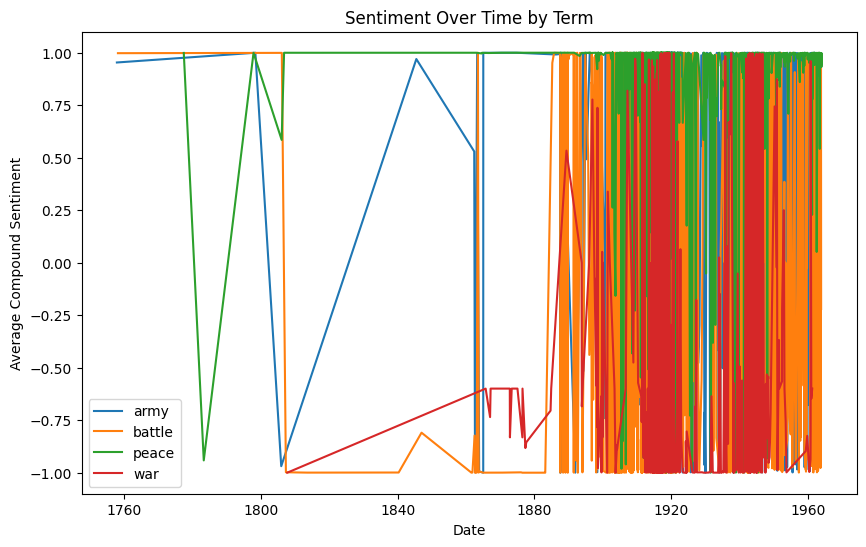

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# If you haven't downloaded VADER before, uncomment and run:
# nltk.download('vader_lexicon')

#####################################
# 1. Reading and Combining Datasets #
#####################################

df_army = pd.read_csv('army.csv', parse_dates=['date'])
df_army['term'] = 'army'

df_battle = pd.read_csv('battle (1).csv', parse_dates=['date'])
df_battle['term'] = 'battle'

df_peace = pd.read_csv('peace.csv', parse_dates=['date'])
df_peace['term'] = 'peace'

df_war = pd.read_csv('war (1).csv', parse_dates=['date'])
df_war['term'] = 'war'

# Combine all into a single DataFrame
combined_df = pd.concat([df_army, df_battle, df_peace, df_war], ignore_index=True)

# If your date column is not already in datetime format, convert it:
combined_df['date'] = pd.to_datetime(combined_df['date'])

combined_df.to_csv('war_term_combined_data.csv', index=False)
###################################################################
# 2. (Optional) Clean the text if you want before sentiment scores #
###################################################################
# Example of minimal cleaning:
# combined_df['clean_text'] = combined_df['text'].str.replace(r'\n+', ' ', regex=True)
# combined_df['clean_text'] = combined_df['clean_text'].str.replace(r'[^\w\s]', '', regex=True)
# combined_df['clean_text'] = combined_df['clean_text'].str.lower()
# Or skip entirely if you're comfortable letting VADER handle raw text:
combined_df['clean_text'] = combined_df['text']  # if your column is named "text"

#############################################
# 3. Compute VADER sentiment for each row   #
#############################################
sia = SentimentIntensityAnalyzer()
combined_df['sentiment'] = combined_df['clean_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

#############################################
# 4. Aggregate sentiment scores over time   #
#############################################
# Let's group by term + date and compute the average sentiment for each date

aggregated = (combined_df
              .groupby([pd.Grouper(key='date', freq='YE'), 'term'])  # freq='M' for monthly, etc.
              .agg({'sentiment': 'mean'})
              .reset_index())


# -- Step 6: Plot monthly sentiment over time --
plt.figure(figsize=(10, 6))

for term in aggregated['term'].unique():
    subset = aggregated[aggregated['term'] == term]
    plt.plot(subset['date'], subset['sentiment'], label=term)

pearl_harbor = pd.to_datetime("1941-12-07")
end_of_war   = pd.to_datetime("1945-09-02")
plt.axvline(x=pearl_harbor, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=end_of_war, color='g', linestyle='--', label="End of War")

plt.legend()
plt.title("Monthly Average Sentiment (1930–1950)")
plt.xlabel("Date")
plt.ylabel("Average Compound Sentiment")
plt.savefig("monthly_sentiment_1930_1950.png")
plt.show()


In [4]:
combined_df.to_csv('war_term_combined_data_with_sentiment.csv', index=False)


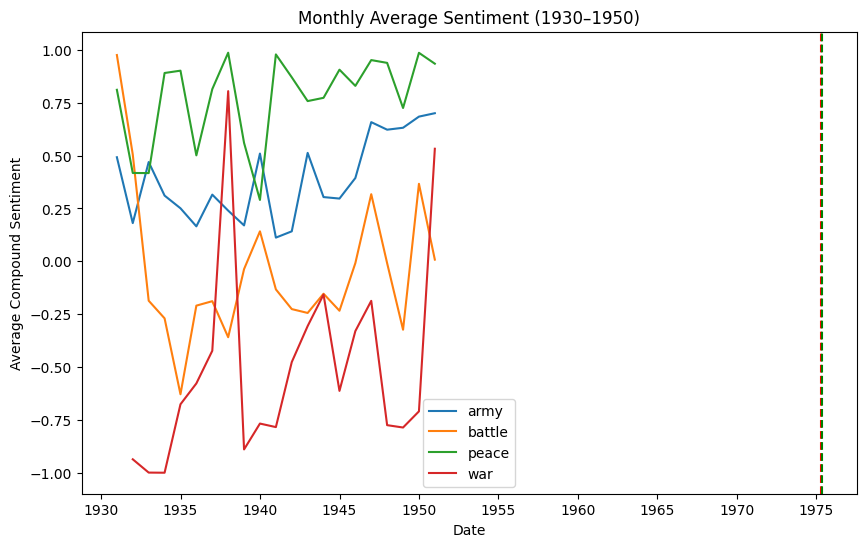

In [10]:
df_1930_1950 = combined_df[
    (combined_df['date'] >= '1930-01-01') &
    (combined_df['date'] < '1950-12-31')
]

# -- Step 5: Aggregate by month --
#   Group by term and monthly buckets, then compute mean sentiment
aggregated = (
    df_1930_1950
    .groupby([pd.Grouper(key='date', freq='YE'), 'term'])
    .agg({'sentiment': 'mean'})
    .reset_index()
)

# -- Step 6: Plot monthly sentiment over time --
plt.figure(figsize=(10, 6))

for term in aggregated['term'].unique():
    subset = aggregated[aggregated['term'] == term]
    plt.plot(subset['date'], subset['sentiment'], label=term)

plt.legend()
plt.axvline(x=1941, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=1945, color='g', linestyle='--', label="End of War")
plt.title("Monthly Average Sentiment (1930–1950)")
plt.xlabel("Date")
plt.ylabel("Average Compound Sentiment")
plt.savefig("monthly_sentiment_1930_1950.png")
plt.show()

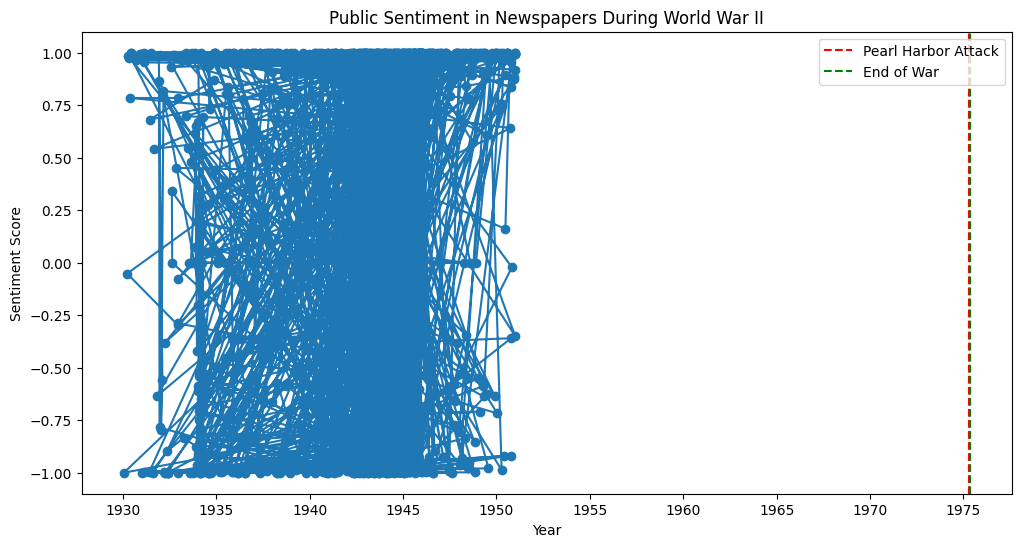

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_1930_1950['date'], df_1930_1950['sentiment'], marker='o', linestyle='-')
plt.axvline(x=1941, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=1945, color='g', linestyle='--', label="End of War")
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.title("Public Sentiment in Newspapers During World War II")
plt.legend()
plt.savefig("ww2_sentiment_trends.png")
plt.show()

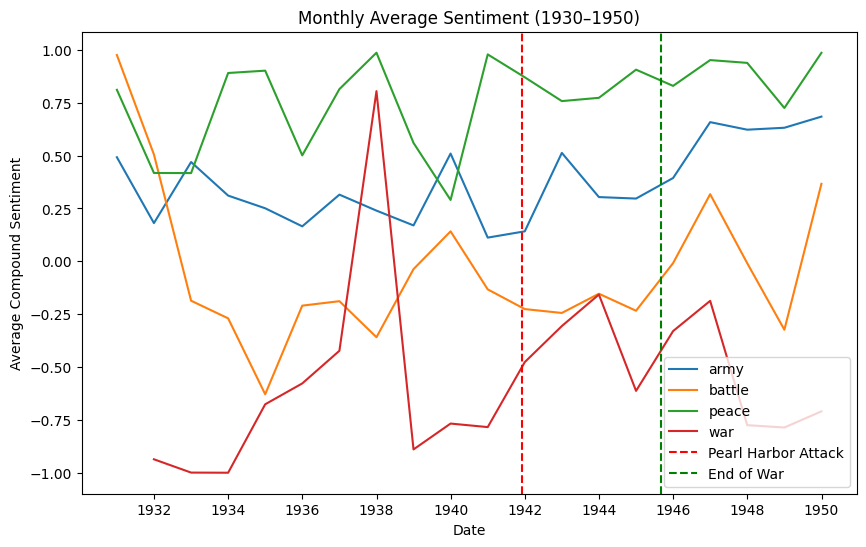

In [12]:

#############################################
# 4. Aggregate sentiment scores over time   #
#############################################
# Let's group by term + date and compute the average sentiment for each date

aggregated = (combined_df
              .groupby([pd.Grouper(key='date', freq='YE'), 'term'])  # freq='M' for monthly, etc.
              .agg({'sentiment': 'mean'})
              .reset_index()
)

aggregated = aggregated[
    (aggregated['date'] >= '1930-01-01') &
    (aggregated['date'] < '1950-12-31')
]

# -- Step 6: Plot monthly sentiment over time --
plt.figure(figsize=(10, 6))

for term in aggregated['term'].unique():
    subset = aggregated[aggregated['term'] == term]
    plt.plot(subset['date'], subset['sentiment'], label=term)

pearl_harbor = pd.to_datetime("1941-12-07")
end_of_war   = pd.to_datetime("1945-09-02")
plt.axvline(x=pearl_harbor, color='r', linestyle='--', label="Pearl Harbor Attack")
plt.axvline(x=end_of_war, color='g', linestyle='--', label="End of War")

plt.legend()
plt.title("Monthly Average Sentiment (1930–1950)")
plt.xlabel("Date")
plt.ylabel("Average Compound Sentiment")
plt.savefig("monthly_sentiment_1930_1950.png")
plt.show()


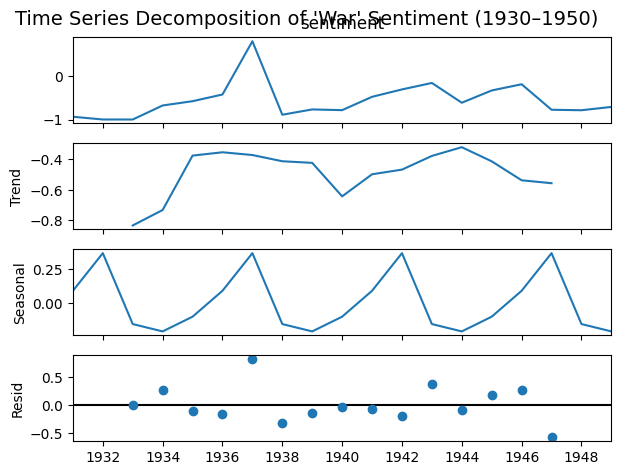

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Filter for 'war' term only
war_df = aggregated[aggregated['term'] == 'war'].copy()


war_df['year'] = war_df['date'].dt.year


war_sentiment = war_df.groupby('year')['sentiment'].mean().reset_index()


war_sentiment.set_index('year', inplace=True)

# Decompose the sentiment time series for 'war'
decomposition = seasonal_decompose(war_sentiment['sentiment'], model='additive', period=5)

# Plot the decomposition
decomposition.plot()
plt.suptitle("Time Series Decomposition of 'War' Sentiment (1930–1950)", fontsize=14)
plt.savefig("war_sentiment_decomposition.png")
plt.show()
